In [7]:
import requests
import csv
import matplotlib.pyplot
import os
import datetime
   

1 Stockholm
2 Göteborg
3 Malmö
4 Uppsala
5 Västerås
6 Örebro
7 Linköping
8 Helsingborg
9 Jönköping
10 Norrköping
11 Oslo
12 Copenhagen
13 Helsinki
14 Berlin
15 Paris
16 Amsterdam
17 Madrid
18 Rome
19 Vienna
20 Prague
21 Warsaw
22 Brussels
23 Lisbon
24 Dublin
25 London



measurement from Malmö
PM10: 6.2 µg/m³
PM2.5 2.6 µg/m³
European AQI: 25
The European air quality index is more than 20 but less than 40 (25).
The air quality is fair


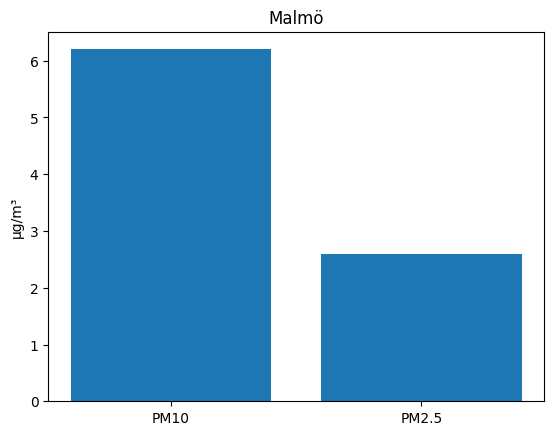

In [ ]:
class CityControl(): # Klass som hanterar städerna

    def cities(): # Metod stad 
        cities = {} # Tom dict

        # Lägger till städerna från cities.csv till tomma dict
        with open("cities.csv", "r", encoding="utf-8") as csv_file:
            csv_reader = csv.reader(csv_file) # läser filen
            next(csv_reader) # Hoppar över första raden då det är titel

            for line in csv_reader: # Loopar igenom varje rad i CSV-filen
                city = line[0]
                latitude = float(line[1].strip())
                longitude = float(line[2].strip())
                cities[city] = [latitude, longitude] # läggs till i dict

            return cities 


    def print_cities(): # Metod som skriver ut städerna
        
        cities = CityControl.cities() # kör cities() metod och sparar värdet i variablen cities 
        city_name = list(cities.keys()) # Hämtar alla nycklar i dict, Stadsnamnen
         
        for number, city in enumerate(city_name, 1): # Loopar igenom stadslistan och skriver både ut nummer och city
            print(number, city)


        return city_name

    def choose_city():
    
        cities = CityControl.cities() # Skapar en metod där användaren får välja vilken stad

        while True: # Startar en loop tills användaren ger giltigt val.
                       
            try: 
            
                city_choice = int(input(f"Choice 1-{len(cities)}: ")) # Valda staden som användaren skriver in. Är anpassningsbar beroende på hur många städer som är i CSV-filen

                if city_choice >= 1 and city_choice <= len(cities): # Kontrollerar att angivna siffran är giltig 
                    return city_choice
                    
                else:
                    print(f"Write a number 1-{len(cities)}") # Frågar igen annars 
                    
            except ValueError:
                    print(f"Write a number 1-{len(cities)}") # Om man tex skriver "Hej" så fångar programmet detta utan att krascha och frågar om ett nummer


def website_info(city_name, cities, city_choice):
    selected_city = city_name[city_choice - 1] #  Tar ut ett värde från listan. Eftersom att listor börjar från 0 så måste man ta -1

    # Tar ut longitud och latitud värdet
    latitude = cities[selected_city][0]
    longitude = cities[selected_city][1]

    try: # Felhantering av API anrop
        get_website = requests.get(f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude={latitude}&longitude={longitude}&current=pm10,pm2_5,european_aqi", timeout=10) # skriver in värdet i adressen så att det passar
        get_website.raise_for_status() # Kontrollerar HTTP statusen 
        get_pm_value = get_website.json() # Svaret är i json format, ser lite ut som en dict

    except requests.exceptions.HTTPError: # Fångar HTTP fel
        print("Error") # Skriver ut ett Error
        print(get_website.status_code) # Visar statuskoden som man får 
        print(get_website.text) # Visar svaret från servern
        return 
    
    except requests.exceptions.RequestException: # Fångar andra problem, tex nätverksproblem eller om det tar mer än 10 sekunder
        print("A request error occurred:")
        return
    
    pm10 = get_pm_value["current"]["pm10"] # Key är "current" och Value är "pm10" 
    pm2_5 = get_pm_value["current"]["pm2_5"]
    european_aqi = get_pm_value["current"]["european_aqi"]

    return pm10, pm2_5, european_aqi, selected_city

    




class Measurement: # Basklass
    def __init__(self, city): 
        self.city = city

    def show_city(self):
        return f"measurement from {self.city}"


class AirQualityMeasurement(Measurement): # barnklass
    def __init__(self, city, pm10, pm2_5, european_aqi): #
        super().__init__(city) # Hämtar data från basklassen
        self.pm10 = pm10
        self.pm2_5 = pm2_5
        self.european_aqi = european_aqi


    def add_data_to_csv(self): # Lägger till data till csv fil


        file_exists = os.path.exists("air_quality_data.csv") # Kollar om filen redan finns
        current_time = datetime.datetime.now() # Tiden just nu


        with open("air_quality_data.csv", "a", newline="", encoding="utf-8") as csv_file: # öppnar filen i lägg till läge, append.
            writer = csv.writer(csv_file) 
            if file_exists == False: # Om filen inte finns så skapas en CSV-fil
                writer.writerow(["city", "pm10", "pm2.5", "european_aqi", "Timestamp"])
            writer.writerow([self.city, self.pm10, self.pm2_5, self.european_aqi, current_time])



    def current_measurement(self): # Visar aktuell mätning
        
        print("")
        print(self.show_city())
        print(f"PM10: {self.pm10} µg/m³")
        print(f"PM2.5 {self.pm2_5} µg/m³")
        print(f"European AQI: {self.european_aqi}")

    def get_aqi_status(self): # Tolkar aqi värdet
        if self.european_aqi <= 20: 
            return(f"The European air quality index is less than 20 ({self.european_aqi}).\nThe air quality is good")

        elif self.european_aqi <= 40:
            return(f"The European air quality index is more than 20 but less than 40 ({self.european_aqi}).\nThe air quality is fair")

        elif self.european_aqi <= 60:
            return(f"The European air quality index is more than 40 but less than 60 ({self.european_aqi}). Consider reducing intense outdoor activities if you experience symptoms.\nThe air quality is Moderate")

        elif self.european_aqi <= 80:
            return(f"The European air quality index is more than 60 but less than 80 ({self.european_aqi}). Consider reducing physical activities, particularly outdoors, especially if you experience symptoms. \nThe air quality is poor")

        elif self.european_aqi <= 100:
            return(f"The European air quality index is more than 80 but less than 100 ({self.european_aqi}) Consider reducing physical activities, particularly outdoors, especially if you experience symptoms. \nThe air quality is very poor")
        else:
            return(f"The European air quality index is more than 100 ({self.european_aqi}) Avoid physical activities outdoors. \nThe air quality is extremely poor")


    def show_chart(self): # Visar ett stapeldiagram 
        labels = ["PM10", "PM2.5"]
        values = [self.pm10, self.pm2_5]

        matplotlib.pyplot.bar(labels, values)
        matplotlib.pyplot.ylabel("µg/m³")
        matplotlib.pyplot.title(self.city)
        matplotlib.pyplot.show()


def main(): 
    cities = CityControl.cities() # Läser in alla städer
    city_name = CityControl.print_cities() # Visar städerna och sparar stadlistan
    chosen_city = CityControl.choose_city() # Frågar användaren vilken stad de vill använda
    result = website_info(city_name, cities, chosen_city) # Skickar informationen till API-funktionen
    
    if result is None: # kollar om API-funktionen misslyckades
        print("Something went wrong. Try again later.") # om ja så avbryts den
        return

    pm10, pm2_5, european_aqi, selected_city = result # Värderna får en variabel
    current_AQ_reading = AirQualityMeasurement(selected_city, pm10, pm2_5, european_aqi) # Skapas ett objekt av klassen airqualitymeasurement
    current_AQ_reading.add_data_to_csv() # Sparar mätningarna
    current_AQ_reading.current_measurement() # Skriver ut mätningarna
    aqi_status = current_AQ_reading.get_aqi_status() # Hämtar AQI beskrivningen
    print(aqi_status) # Skriver ut aqi texten
    current_AQ_reading.show_chart() # Visar stapeldiagrammet
    
    

main() # Startar hela programmet
